In [1]:
# Task 5: Data Analysis on CSV Files
# Sales Data Analysis using Pandas

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


# Task 5: Data Analysis on CSV Files

## Sales Data Analysis Using Pandas

### Objective
To analyze sales data using Python and Pandas and identify useful insights through data analysis and visualization.

### Tools Used
- Python
- Pandas
- Matplotlib
- Jupyter Notebook

### Analysis Performed
- CSV data loading
- Dataset inspection
- Statistical summary
- Missing-value analysis
- Product-wise sales analysis
- Region-wise sales analysis
- Monthly sales trend analysis
- Data filtering
- Data selection using `loc` and `iloc`
- Data visualization using charts

In [2]:
# Creating sample sales data

data = {
    "Date": [
        "2026-01-05", "2026-01-10", "2026-01-15", "2026-01-20",
        "2026-02-03", "2026-02-08", "2026-02-14", "2026-02-25",
        "2026-03-02", "2026-03-11", "2026-03-18", "2026-03-27",
        "2026-04-04", "2026-04-12", "2026-04-20", "2026-04-28",
        "2026-05-06", "2026-05-15", "2026-05-22", "2026-05-30"
    ],
    "Product": [
        "Laptop", "Mouse", "Keyboard", "Monitor",
        "Laptop", "Keyboard", "Mouse", "Monitor",
        "Laptop", "Mouse", "Keyboard", "Monitor",
        "Laptop", "Keyboard", "Mouse", "Monitor",
        "Laptop", "Mouse", "Keyboard", "Monitor"
    ],
    "Region": [
        "North", "South", "East", "West",
        "North", "East", "South", "West",
        "North", "South", "East", "West",
        "North", "East", "South", "West",
        "North", "South", "East", "West"
    ],
    "Quantity": [
        5, 20, 15, 8,
        6, 18, 25, 10,
        7, 22, 20, 12,
        8, 24, 28, 14,
        9, 26, 22, 16
    ],
    "Unit_Price": [
        60000, 800, 1500, 12000,
        60000, 1500, 800, 12000,
        60000, 800, 1500, 12000,
        60000, 1500, 800, 12000,
        60000, 800, 1500, 12000
    ]
}

df = pd.DataFrame(data)

df["Date"] = pd.to_datetime(df["Date"])
df["Sales"] = df["Quantity"] * df["Unit_Price"]

df.to_csv("sales_data.csv", index=False)

print("sales_data.csv created successfully!")


sales_data.csv created successfully!


In [3]:
# Loading the CSV file

df = pd.read_csv("sales_data.csv")

print("CSV file loaded successfully!")

CSV file loaded successfully!


In [4]:
# Displaying the first 5 rows of the dataset

df.head()

,Date,Product,Region,Quantity,Unit_Price,Sales
0,2026-01-05,Laptop,North,5,60000,300000
1,2026-01-10,Mouse,South,20,800,16000
2,2026-01-15,Keyboard,East,15,1500,22500
3,2026-01-20,Monitor,West,8,12000,96000
4,2026-02-03,Laptop,North,6,60000,360000


In [5]:
# Checking dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Date        20 non-null     str  
 1   Product     20 non-null     str  
 2   Region      20 non-null     str  
 3   Quantity    20 non-null     int64
 4   Unit_Price  20 non-null     int64
 5   Sales       20 non-null     int64
dtypes: int64(3), str(3)
memory usage: 1.1 KB


In [6]:
# Checking the number of rows and columns

df.shape

(20, 6)

In [7]:
# Statistical summary of numerical columns

df.describe()

,Quantity,Unit_Price,Sales
count,20.000000,20.000000,20.00000
mean,15.750000,18575.000000,153265.00000
std,7.369032,24956.633439,172299.80076
min,5.000000,800.000000,16000.00000
25%,8.750000,1325.000000,22475.00000
50%,15.500000,6750.000000,66000.00000
75%,22.000000,24000.000000,219000.00000
max,28.000000,60000.000000,540000.00000


In [8]:
# Checking for missing values

df.isnull().sum()

Date          0
Product       0
Region        0
Quantity      0
Unit_Price    0
Sales         0
dtype: int64

In [9]:
# Total sales by product

product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)

print("Total Sales by Product:")
print(product_sales)

Total Sales by Product:
Product
Laptop      2100000
Monitor      720000
Keyboard     148500
Mouse         96800
Name: Sales, dtype: int64


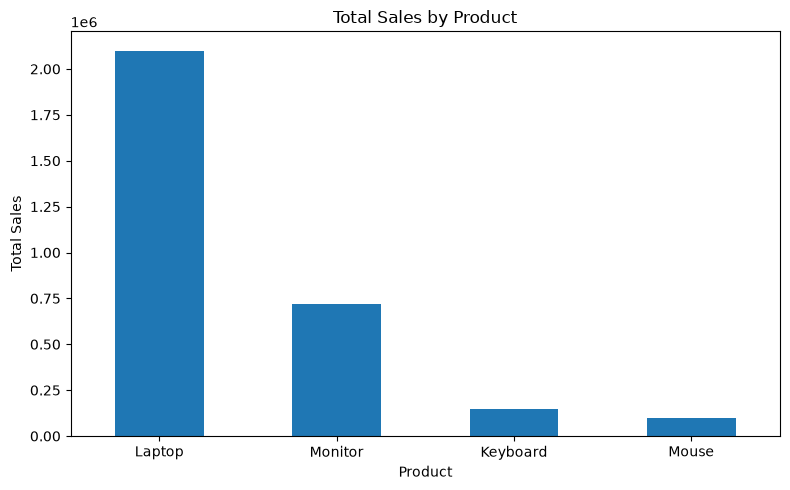

In [10]:
# Bar chart for product-wise sales

product_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales by Product")
plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("05_product_sales_chart.png")
plt.show()

In [11]:
# Total sales by region

region_sales = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

print("Total Sales by Region:")
print(region_sales)

Total Sales by Region:
Region
North    2100000
West      720000
East      148500
South      96800
Name: Sales, dtype: int64


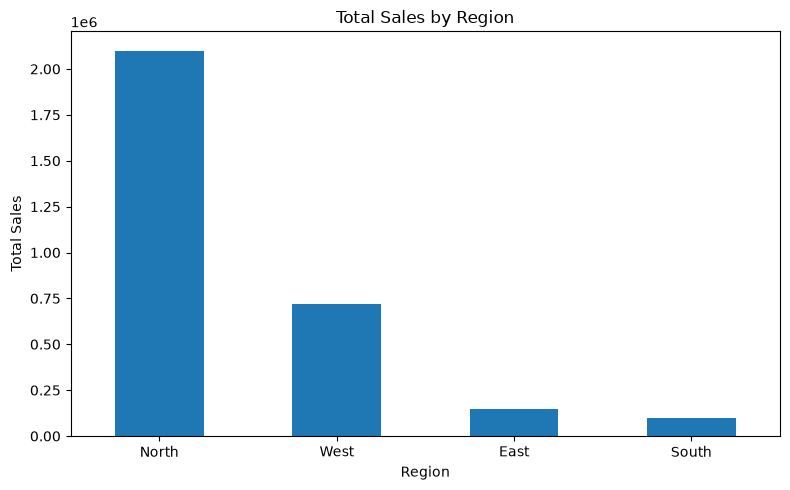

In [12]:
# Bar chart for region-wise sales

region_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("06_region_sales_chart.png")
plt.show()


In [13]:
# Monthly sales analysis

df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

print("Monthly Sales:")
print(monthly_sales)

AttributeError: Can only use .dt accessor with datetimelike values

In [14]:
# Monthly sales analysis

df["Date"] = pd.to_datetime(df["Date"])

df["Month"] = df["Date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

print("Monthly Sales:")
print(monthly_sales)

Monthly Sales:
Month
2026-01    434500
2026-02    527000
2026-03    611600
2026-04    706400
2026-05    785800
Name: Sales, dtype: int64


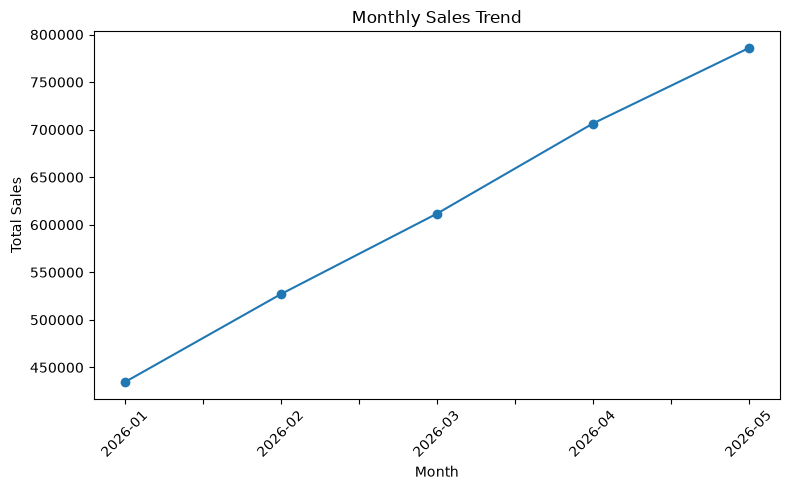

In [15]:
# Line chart for monthly sales

monthly_sales.plot(kind="line", marker="o", figsize=(8, 5))

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("07_monthly_sales_chart.png")
plt.show()

In [16]:
# Finding the highest-selling product and region

highest_product = product_sales.idxmax()
highest_product_sales = product_sales.max()

highest_region = region_sales.idxmax()
highest_region_sales = region_sales.max()

print("Highest-Selling Product:", highest_product)
print("Product Sales:", highest_product_sales)

print("\nHighest-Sales Region:", highest_region)
print("Region Sales:", highest_region_sales)

Highest-Selling Product: Laptop
Product Sales: 2100000

Highest-Sales Region: North
Region Sales: 2100000


In [17]:
# Filtering products with sales greater than 100,000

high_sales = df[df["Sales"] > 100000]

print("Products with Sales greater than 100,000:")
print(high_sales[["Date", "Product", "Region", "Sales"]])

Products with Sales greater than 100,000:
         Date  Product Region   Sales
0  2026-01-05   Laptop  North  300000
4  2026-02-03   Laptop  North  360000
7  2026-02-25  Monitor   West  120000
8  2026-03-02   Laptop  North  420000
11 2026-03-27  Monitor   West  144000
12 2026-04-04   Laptop  North  480000
15 2026-04-28  Monitor   West  168000
16 2026-05-06   Laptop  North  540000
19 2026-05-30  Monitor   West  192000


In [18]:
# Using loc to select specific columns

selected_data = df.loc[:, ["Product", "Region", "Sales"]]

print("Selected columns using loc:")
print(selected_data.head(10))

Selected columns using loc:
    Product Region   Sales
0    Laptop  North  300000
1     Mouse  South   16000
2  Keyboard   East   22500
3   Monitor   West   96000
4    Laptop  North  360000
5  Keyboard   East   27000
6     Mouse  South   20000
7   Monitor   West  120000
8    Laptop  North  420000
9     Mouse  South   17600


In [19]:
# Using iloc to select rows and columns by position

print("Selected data using iloc:")
print(df.iloc[:5, :3])

Selected data using iloc:
        Date   Product Region
0 2026-01-05    Laptop  North
1 2026-01-10     Mouse  South
2 2026-01-15  Keyboard   East
3 2026-01-20   Monitor   West
4 2026-02-03    Laptop  North


In [20]:
# Total quantity sold by product

quantity_by_product = (
    df.groupby("Product")["Quantity"]
    .sum()
    .sort_values(ascending=False)
)

print("Total Quantity Sold by Product:")
print(quantity_by_product)

Total Quantity Sold by Product:
Product
Mouse       121
Keyboard     99
Monitor      60
Laptop       35
Name: Quantity, dtype: int64


In [21]:
# Key insights from the sales analysis

print("KEY INSIGHTS")
print("-" * 40)

print(f"1. Highest-selling product: {highest_product}")
print(f"   Total sales: ₹{highest_product_sales:,.0f}")

print(f"2. Highest-sales region: {highest_region}")
print(f"   Total sales: ₹{highest_region_sales:,.0f}")

print(f"3. Total sales: ₹{df['Sales'].sum():,.0f}")
print(f"4. Total quantity sold: {df['Quantity'].sum():,}")

KEY INSIGHTS
----------------------------------------
1. Highest-selling product: Laptop
   Total sales: ₹2,100,000
2. Highest-sales region: North
   Total sales: ₹2,100,000
3. Total sales: ₹3,065,300
4. Total quantity sold: 315


## Conclusion

The sales data was analyzed using Python and Pandas. The analysis included data loading, statistical summary, missing-value checking, product-wise sales, region-wise sales, monthly sales trends, filtering, and data selection using `loc` and `iloc`.

The analysis shows that Laptop generated the highest total sales, while the North region recorded the highest sales. Monthly sales also showed an increasing trend from January to May.

Overall, Pandas and data visualization provided useful insights into the sales performance and helped identify important patterns in the dataset.

In [22]:
from pathlib import Path
from shutil import move

charts_folder = Path("charts")
charts_folder.mkdir(exist_ok=True)

chart_files = Path(".").glob("*_chart.png")

for file in chart_files:
    move(str(file), charts_folder / file.name)

print("All charts moved to the charts folder successfully!")

All charts moved to the charts folder successfully!


In [23]:
from pathlib import Path
from shutil import move

screenshots_folder = Path("screenshots")
screenshots_folder.mkdir(exist_ok=True)

screenshot_files = Path(".").glob("*.png")

for file in screenshot_files:
    if file.parent == Path("."):
        move(str(file), screenshots_folder / file.name)

print("All screenshots moved to the screenshots folder successfully!")

All screenshots moved to the screenshots folder successfully!


## Project Summary

This project analyzes sales data using Python and Pandas. The dataset contains information about products, regions, quantities, unit prices, and sales values.

The analysis identifies product-wise and region-wise sales performance, monthly sales trends, missing values, statistical information, and important business insights.

### Key Findings

- Laptop generated the highest total sales.
- North region recorded the highest total sales.
- Monthly sales increased consistently from January to May.
- No missing values were found in the dataset.
- Pandas `groupby()`, filtering, `loc`, and `iloc` were used for data analysis.
- Matplotlib was used to visualize sales trends and comparisons.
- 